# Sentiment Analysis

Notebook ini menjelaskan modul sentiment analysis untuk project aluminium INALUM.

Fokus notebook ini sederhana:

- berita apa yang dipakai,
- bagaimana berita diberi skor,
- bagaimana skor harian dibaca,
- dan bagaimana sentiment membantu membaca konteks pasar.

Notebook ini **bukan** notebook model harga. Perannya adalah menjelaskan sisi **news sentiment** secara ringkas, jelas, dan mudah dibaca.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)
plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SCORED_PATH = ROOT / "data" / "news" / "scored" / "gdelt_backfill_180d_english_v2_candidate_model_scored.csv"
DAILY_PATH = ROOT / "data" / "news" / "features" / "gdelt_backfill_180d_english_v2_daily_sentiment.csv"
PRICE_PATH = ROOT / "data" / "processed data" / "ali_f_event_model_ready_v3.csv"

scored = pd.read_csv(SCORED_PATH, parse_dates=["news_date", "news_datetime"])
daily = pd.read_csv(DAILY_PATH, parse_dates=["news_date"])
price = pd.read_csv(PRICE_PATH, parse_dates=["Date"])[["Date", "Close"]].sort_values("Date")

scored["impact_label_readable"] = scored["impact_label"].map(
    {"bullish": "Cenderung naik", "bearish": "Cenderung turun", "neutral": "Netral"}
)
scored["impact_channel_readable"] = scored["impact_channel"].map(
    {
        "price": "Harga pasar",
        "supply": "Pasokan",
        "policy": "Kebijakan",
        "logistics": "Logistik",
        "inventory": "Persediaan",
        "demand": "Permintaan",
        "macro": "Makro",
        "unclear": "Belum jelas",
    }
).fillna(scored["impact_channel"])

calendar = pd.DatetimeIndex(sorted(price["Date"].dropna().unique()))
positions = calendar.searchsorted(daily["news_date"].values, side="left")
positions = positions.clip(0, len(calendar) - 1)
daily["trade_date"] = calendar[positions]

price["close_t1"] = price["Close"].shift(-1)
price["ret_t1_pct"] = (price["close_t1"] / price["Close"] - 1.0) * 100
daily_market = daily.merge(
    price[["Date", "Close", "close_t1", "ret_t1_pct"]],
    left_on="trade_date",
    right_on="Date",
    how="left",
)

channel_cols = [
    "channel_price_count",
    "channel_supply_count",
    "channel_policy_count",
    "channel_logistics_count",
    "channel_inventory_count",
    "channel_demand_count",
    "channel_macro_count",
    "channel_unclear_count",
]
channel_name_map = {
    "channel_price_count": "Harga pasar",
    "channel_supply_count": "Pasokan",
    "channel_policy_count": "Kebijakan",
    "channel_logistics_count": "Logistik",
    "channel_inventory_count": "Persediaan",
    "channel_demand_count": "Permintaan",
    "channel_macro_count": "Makro",
    "channel_unclear_count": "Belum jelas",
}
daily_market["channel_utama"] = (
    daily_market[channel_cols]
    .idxmax(axis=1)
    .map(channel_name_map)
)


## Peran sentiment di project


In [2]:
role_table = pd.DataFrame(
    [
        {
            "Bagian": "Sumber berita",
            "Isi singkat": "Berita pasar aluminium yang sudah lolos seleksi relevansi",
            "Tujuan": "Mengambil berita yang benar-benar dekat dengan harga, pasokan, logistik, atau kebijakan",
        },
        {
            "Bagian": "Skor per artikel",
            "Isi singkat": "Setiap artikel diberi skor dampak ke pasar aluminium",
            "Tujuan": "Menyederhanakan berita menjadi sinyal yang mudah dibaca",
        },
        {
            "Bagian": "Ringkasan harian",
            "Isi singkat": "Skor artikel diringkas per hari",
            "Tujuan": "Melihat nada pasar harian secara cepat",
        },
        {
            "Bagian": "Pemakaian di project",
            "Isi singkat": "Sebagai konteks pasar dan penjelas tambahan",
            "Tujuan": "Membantu membaca kondisi pasar, bukan menggantikan model harga",
        },
    ]
)
display(role_table)


,Bagian,Isi singkat,Tujuan
0,Sumber berita,Berita pasar aluminium yang sudah lolos seleksi relevansi,"Mengambil berita yang benar-benar dekat dengan harga, pasokan, logistik, atau kebijakan"
1,Skor per artikel,Setiap artikel diberi skor dampak ke pasar aluminium,Menyederhanakan berita menjadi sinyal yang mudah dibaca
2,Ringkasan harian,Skor artikel diringkas per hari,Melihat nada pasar harian secara cepat
3,Pemakaian di project,Sebagai konteks pasar dan penjelas tambahan,"Membantu membaca kondisi pasar, bukan menggantikan model harga"


## Cara membaca skor


In [3]:
score_guide = pd.DataFrame(
    [
        {"Nilai skor": "+1", "Arti sederhana": "Sangat mendorong harga naik", "Cara baca": "Berita sangat bullish untuk aluminium"},
        {"Nilai skor": "0", "Arti sederhana": "Netral", "Cara baca": "Tidak ada dorongan arah yang kuat"},
        {"Nilai skor": "-1", "Arti sederhana": "Sangat mendorong harga turun", "Cara baca": "Berita sangat bearish untuk aluminium"},
    ]
)

channel_guide = pd.DataFrame(
    [
        {"Channel": "Harga pasar", "Makna": "Berita yang langsung membahas harga aluminium atau market move"},
        {"Channel": "Pasokan", "Makna": "Berita tentang produksi, smelter, refinery, atau gangguan pasokan"},
        {"Channel": "Logistik", "Makna": "Berita pengiriman, pelabuhan, jalur laut, atau gangguan transportasi"},
        {"Channel": "Kebijakan", "Makna": "Berita tarif, sanksi, ekspor, atau kebijakan pemerintah"},
        {"Channel": "Persediaan", "Makna": "Berita stok, warehouse, atau level inventory"},
        {"Channel": "Permintaan", "Makna": "Berita sisi konsumsi atau penggunaan aluminium"},
        {"Channel": "Makro", "Makna": "Berita makro umum yang bisa memengaruhi pasar"},
    ]
)

display(score_guide)
display(channel_guide)


,Nilai skor,Arti sederhana,Cara baca
0,+1,Sangat mendorong harga naik,Berita sangat bullish untuk aluminium
1,0,Netral,Tidak ada dorongan arah yang kuat
2,-1,Sangat mendorong harga turun,Berita sangat bearish untuk aluminium


,Channel,Makna
0,Harga pasar,Berita yang langsung membahas harga aluminium atau market move
1,Pasokan,"Berita tentang produksi, smelter, refinery, atau gangguan pasokan"
2,Logistik,"Berita pengiriman, pelabuhan, jalur laut, atau gangguan transportasi"
3,Kebijakan,"Berita tarif, sanksi, ekspor, atau kebijakan pemerintah"
4,Persediaan,"Berita stok, warehouse, atau level inventory"
5,Permintaan,Berita sisi konsumsi atau penggunaan aluminium
6,Makro,Berita makro umum yang bisa memengaruhi pasar


## Ringkasan data yang digunakan


In [4]:
top_channel = (
    scored["impact_channel_readable"]
    .value_counts()
    .idxmax()
)

summary_table = pd.DataFrame(
    [
        {"Ringkasan": "Jumlah artikel", "Nilai": int(len(scored)), "Makna": "Total artikel yang sudah diberi skor sentiment"},
        {"Ringkasan": "Jumlah hari berita", "Nilai": int(daily['news_date'].nunique()), "Makna": "Jumlah hari yang memiliki berita relevan"},
        {"Ringkasan": "Rentang tanggal", "Nilai": f"{scored['news_date'].min().date()} s.d. {scored['news_date'].max().date()}", "Makna": "Periode berita yang sedang dibaca modul sentiment"},
        {"Ringkasan": "Rata-rata skor", "Nilai": round(float(scored['market_impact_score'].mean()), 4), "Makna": "Semakin positif berarti tone berita cenderung mendukung harga naik"},
        {"Ringkasan": "Rata-rata confidence", "Nilai": round(float(scored['confidence'].mean()), 4), "Makna": "Seberapa yakin penilaian sentiment pada artikel"},
        {"Ringkasan": "Channel paling sering muncul", "Nilai": top_channel, "Makna": "Tema berita yang paling dominan pada data saat ini"},
    ]
)
display(summary_table)

latest_articles = (
    scored.sort_values("news_datetime", ascending=False)[
        [
            "news_date",
            "title",
            "impact_label_readable",
            "impact_channel_readable",
            "market_impact_score",
            "confidence",
            "reason_short",
        ]
    ]
    .head(8)
    .rename(
        columns={
            "news_date": "Tanggal",
            "title": "Judul berita",
            "impact_label_readable": "Arah",
            "impact_channel_readable": "Channel",
            "market_impact_score": "Skor",
            "confidence": "Confidence",
            "reason_short": "Alasan singkat",
        }
    )
)
display(latest_articles)


,Ringkasan,Nilai,Makna
0,Jumlah artikel,38,Total artikel yang sudah diberi skor sentiment
1,Jumlah hari berita,30,Jumlah hari yang memiliki berita relevan
2,Rentang tanggal,2025-09-22 s.d. 2026-03-09,Periode berita yang sedang dibaca modul sentiment
3,Rata-rata skor,0.2079,Semakin positif berarti tone berita cenderung mendukung harga naik
4,Rata-rata confidence,0.6868,Seberapa yakin penilaian sentiment pada artikel
5,Channel paling sering muncul,Pasokan,Tema berita yang paling dominan pada data saat ini


,Tanggal,Judul berita,Arah,Channel,Skor,Confidence,Alasan singkat
0,2026-03-09,Aluminium makers ride on underlying price rise - The HinduBusinessLine,Cenderung naik,Harga pasar,0.6,0.70,"The title indicates that aluminium producers are benefiting from an underlying rise in market prices, signaling a positive price trend."
1,2026-03-09,"Aluminum Follows Oil , Soaring As Persian Gulf Shipping Is Squeezed",Cenderung naik,Logistik,0.8,0.85,"Shipping disruptions in the Persian Gulf increase freight costs and risk supply delays, while rising oil prices boost aluminum production costs."
2,2026-03-04,How long will Gulf disruptions support aluminum prices ? | Hellenic Shipping News Worldwide,Cenderung naik,Logistik,0.4,0.60,"Disruptions in the Gulf region typically constrain supply or increase shipping costs, which supports higher aluminum prices."
3,2026-03-04,Aluminum price surges to 4 - year high on Bahrain force majeure,Cenderung naik,Pasokan,0.9,0.95,"A force majeure in Bahrain indicates a significant supply disruption, which is a strong driver for higher aluminum prices."
4,2026-03-03,Geopolitical risks in Middle East seen tightening Asian aluminum market | Hellenic Shipping News Worldwide,Cenderung naik,Pasokan,0.7,0.85,"Geopolitical risks in the Middle East are expected to tighten supply in the Asian aluminum market, exerting upward pressure on prices."
5,2026-03-02,Aluminum price jumps as Iran conflict puts Middle East supply at risk,Cenderung naik,Pasokan,0.8,0.90,"Geopolitical conflict in the Middle East poses a significant risk to regional aluminum production and export routes, driving prices higher."
6,2026-02-26,"Press Metal 4Q profit jumps 32 %, sees steady FY26 on firmer aluminium prices",Cenderung naik,Harga pasar,0.6,0.80,"Press Metal reports higher profits and expects firmer aluminium prices through FY26, signaling positive market sentiment and price support."
7,2026-02-24,"[ SMM Analysis ] Global Macro Mildly Positive , Aluminum Market Sees Short - Term Volatility Awaiting Demand Recovery",Netral,Makro,0.1,0.60,Mildly positive macro outlook is offset by short-term volatility and the market still awaiting a concrete recovery in demand.


## Visual utama


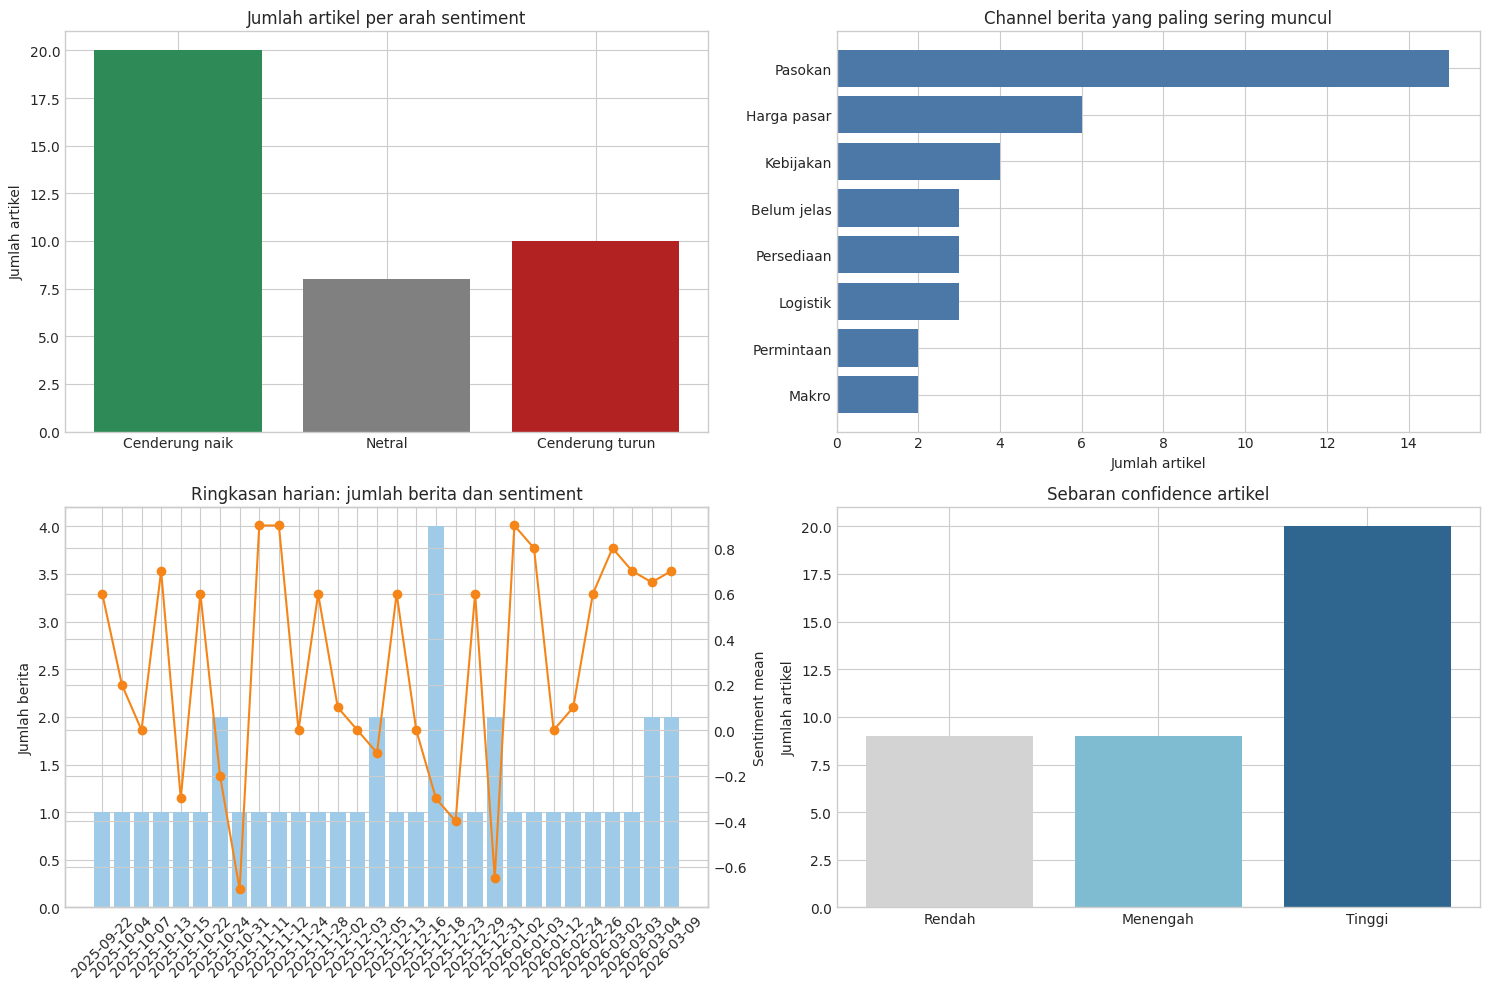

In [5]:
label_counts = (
    scored["impact_label_readable"]
    .value_counts()
    .reindex(["Cenderung naik", "Netral", "Cenderung turun"])
    .fillna(0)
)
channel_counts = scored["impact_channel_readable"].value_counts().sort_values(ascending=True)
trend = daily.sort_values("news_date").copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].bar(label_counts.index, label_counts.values, color=["#2E8B57", "#808080", "#B22222"])
axes[0, 0].set_title("Jumlah artikel per arah sentiment")
axes[0, 0].set_ylabel("Jumlah artikel")

axes[0, 1].barh(channel_counts.index, channel_counts.values, color="#4C78A8")
axes[0, 1].set_title("Channel berita yang paling sering muncul")
axes[0, 1].set_xlabel("Jumlah artikel")

axes[1, 0].bar(trend["news_date"].dt.strftime("%Y-%m-%d"), trend["news_count_model"], color="#A0CBE8", label="Jumlah berita")
ax2 = axes[1, 0].twinx()
ax2.plot(trend["news_date"].dt.strftime("%Y-%m-%d"), trend["market_sentiment_mean"], color="#F58518", marker="o", label="Sentiment mean")
axes[1, 0].set_title("Ringkasan harian: jumlah berita dan sentiment")
axes[1, 0].set_ylabel("Jumlah berita")
ax2.set_ylabel("Sentiment mean")
axes[1, 0].tick_params(axis="x", rotation=45)

conf_bins = pd.cut(scored["confidence"], bins=[0, 0.59, 0.74, 1.0], labels=["Rendah", "Menengah", "Tinggi"], include_lowest=True)
conf_counts = conf_bins.value_counts().reindex(["Rendah", "Menengah", "Tinggi"]).fillna(0)
axes[1, 1].bar(conf_counts.index, conf_counts.values, color=["#D3D3D3", "#7FBCD2", "#2F6690"])
axes[1, 1].set_title("Sebaran confidence artikel")
axes[1, 1].set_ylabel("Jumlah artikel")

plt.tight_layout()
plt.show()


## Hari yang paling kuat


In [6]:
strongest_positive = (
    daily_market.sort_values(["market_sentiment_mean", "news_count_model"], ascending=[False, False])[
        ["news_date", "news_count_model", "market_sentiment_mean", "bullish_ratio", "bearish_ratio", "channel_utama"]
    ]
    .head(5)
    .copy()
)
strongest_negative = (
    daily_market.sort_values(["market_sentiment_mean", "news_count_model"], ascending=[True, False])[
        ["news_date", "news_count_model", "market_sentiment_mean", "bullish_ratio", "bearish_ratio", "channel_utama"]
    ]
    .head(5)
    .copy()
)

strongest_positive["Bacaan sederhana"] = "Tone harian kuat ke arah naik"
strongest_negative["Bacaan sederhana"] = "Tone harian kuat ke arah turun"

strongest_positive = strongest_positive.rename(
    columns={
        "news_date": "Tanggal",
        "news_count_model": "Jumlah berita",
        "market_sentiment_mean": "Sentiment mean",
        "bullish_ratio": "Rasio bullish",
        "bearish_ratio": "Rasio bearish",
        "channel_utama": "Channel utama",
    }
)
strongest_negative = strongest_negative.rename(
    columns={
        "news_date": "Tanggal",
        "news_count_model": "Jumlah berita",
        "market_sentiment_mean": "Sentiment mean",
        "bullish_ratio": "Rasio bullish",
        "bearish_ratio": "Rasio bearish",
        "channel_utama": "Channel utama",
    }
)

display(Markdown("**Hari paling bullish**"))
display(strongest_positive)
display(Markdown("**Hari paling bearish**"))
display(strongest_negative)


**Hari paling bullish**

,Tanggal,Jumlah berita,Sentiment mean,Rasio bullish,Rasio bearish,Channel utama,Bacaan sederhana
8,2025-11-11,1,0.9,1.0,0.0,Kebijakan,Tone harian kuat ke arah naik
9,2025-11-12,1,0.9,1.0,0.0,Kebijakan,Tone harian kuat ke arah naik
21,2026-01-02,1,0.9,1.0,0.0,Pasokan,Tone harian kuat ke arah naik
22,2026-01-03,1,0.8,1.0,0.0,Pasokan,Tone harian kuat ke arah naik
26,2026-03-02,1,0.8,1.0,0.0,Pasokan,Tone harian kuat ke arah naik


**Hari paling bearish**

,Tanggal,Jumlah berita,Sentiment mean,Rasio bullish,Rasio bearish,Channel utama,Bacaan sederhana
7,2025-10-31,1,-0.70,0.0,1.00,Permintaan,Tone harian kuat ke arah turun
20,2025-12-31,2,-0.65,0.0,1.00,Pasokan,Tone harian kuat ke arah turun
18,2025-12-23,1,-0.40,0.0,1.00,Persediaan,Tone harian kuat ke arah turun
17,2025-12-18,4,-0.30,0.0,0.75,Pasokan,Tone harian kuat ke arah turun
4,2025-10-15,1,-0.30,0.0,1.00,Logistik,Tone harian kuat ke arah turun


## Hubungan ringkas ke pasar


,Kelompok sentiment,Jumlah hari,Rata-rata sentiment,Rata-rata return T+1 (%)
0,Negatif kuat,5,-0.47,1.111638
1,Netral / lemah,10,0.01,0.613487
2,Positif kuat,15,0.71,1.117427


,Tanggal berita,Tanggal pasar,Jumlah berita,Sentiment mean,Channel utama,Return T+1 (%)
29,2026-03-09,2026-03-04,2,0.70,Harga pasar,NaN
28,2026-03-04,2026-03-04,2,0.65,Pasokan,NaN
27,2026-03-03,2026-03-03,1,0.70,Pasokan,2.921898
26,2026-03-02,2026-03-02,1,0.80,Pasokan,1.817158
25,2026-02-26,2026-02-26,1,0.60,Harga pasar,-0.895255
24,2026-02-24,2026-02-24,1,0.10,Makro,2.019366
23,2026-01-12,2026-01-12,1,0.00,Persediaan,0.534629
22,2026-01-03,2026-01-05,1,0.80,Pasokan,1.453488
21,2026-01-02,2026-01-02,1,0.90,Pasokan,2.450647
20,2025-12-31,2025-12-31,2,-0.65,Pasokan,1.092473


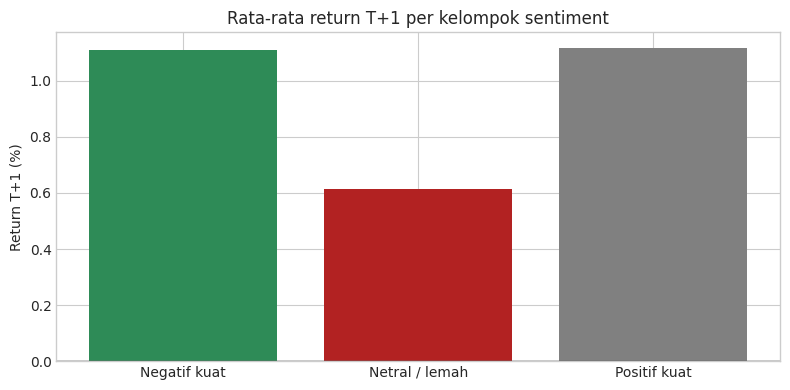

In [7]:
relation = daily_market.copy()
relation["Kelompok sentiment"] = np.select(
    [
        relation["market_sentiment_mean"] > 0.20,
        relation["market_sentiment_mean"] < -0.20,
    ],
    [
        "Positif kuat",
        "Negatif kuat",
    ],
    default="Netral / lemah",
)

relation_summary = (
    relation.groupby("Kelompok sentiment", as_index=False)
    .agg(
        {
            "news_date": "count",
            "market_sentiment_mean": "mean",
            "ret_t1_pct": "mean",
        }
    )
    .rename(
        columns={
            "news_date": "Jumlah hari",
            "market_sentiment_mean": "Rata-rata sentiment",
            "ret_t1_pct": "Rata-rata return T+1 (%)",
        }
    )
)
display(relation_summary)

recent_relation = (
    relation.sort_values("news_date", ascending=False)[
        [
            "news_date",
            "trade_date",
            "news_count_model",
            "market_sentiment_mean",
            "channel_utama",
            "ret_t1_pct",
        ]
    ]
    .head(10)
    .rename(
        columns={
            "news_date": "Tanggal berita",
            "trade_date": "Tanggal pasar",
            "news_count_model": "Jumlah berita",
            "market_sentiment_mean": "Sentiment mean",
            "channel_utama": "Channel utama",
            "ret_t1_pct": "Return T+1 (%)",
        }
    )
)
display(recent_relation)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    relation_summary["Kelompok sentiment"],
    relation_summary["Rata-rata return T+1 (%)"],
    color=["#2E8B57", "#B22222", "#808080"] if len(relation_summary) == 3 else "#4C78A8",
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Rata-rata return T+1 per kelompok sentiment")
ax.set_ylabel("Return T+1 (%)")
plt.tight_layout()
plt.show()


## Kesimpulan

- Modul ini mengubah berita pasar aluminium menjadi **skor yang bisa dibaca**.
- Output utamanya adalah:
  - arah sentiment,
  - channel utama berita,
  - dan ringkasan harian sentiment.
- Peran sentiment di project adalah **membantu membaca konteks pasar**, bukan menggantikan model harga.
- Jadi cara membaca notebook ini sederhana:
  - jika sentiment harian kuat, berarti ada konteks berita yang patut diperhatikan,
  - jika sentiment lemah, berarti pasar hari itu lebih banyak digerakkan faktor lain.
